# Plot pcFVA Results

In [1]:
import os
from pathlib import Path
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
model_id = "RBC3P_expanded"
dataset_name = "RBComics_G6PD"
data_path = Path("../../../../data/analysis/OVERLAY").resolve()
root_path = Path("../../../..").resolve()
results_path = root_path / "data" / "processed" / model_id / "OVERLAY"
pcmodel_dirpath = data_path / model_id
dataset_path = results_path / dataset_name
dataset_models_dirpath = dataset_path / "pcmodels"
pcfva_results_dirpath = dataset_path / "pcFVA"
corr_results_dirpath = dataset_path / "correlations"
df_pcfva_all_filename = pcfva_results_dirpath / f"{model_id}_PC_FVAresults_ALL.tsv"
model_filename = pcmodel_dirpath / f"{model_id}.xml"
pcmodel_filename = pcmodel_dirpath / f"{model_id}_PC.xml"
correlations2_dirpath = dataset_path / "correlations2"

print(results_path)
print(pcmodel_dirpath)
print(dataset_path)
print(dataset_models_dirpath)
print(pcfva_results_dirpath)
print(corr_results_dirpath)
print(df_pcfva_all_filename)
print(model_filename)
print(pcmodel_filename)
print(correlations2_dirpath)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcmodels
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA\RBC3P_expanded_PC_FVAresults_ALL.tsv
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded\RBC3P_expanded.xml
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded\RBC3P_expanded_PC.xml
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations2


In [3]:
df_flux_abundance_correlation_filename = (
    correlations2_dirpath / "df_flux_abundance_correlation.csv"
)
df_flux_abundance_correlation = pd.read_csv(df_flux_abundance_correlation_filename)
df_flux_abundance_correlation

,Unnamed: 0,reactions,rho,raw_p_value,adj_p_value,neg_log10_adj_p_value,abundance_dependence,subsystem
0,0,ADA,-0.069060,3.135064e-03,4.068913e-03,2.390522,Independent,Purine metabolism
1,1,ADEt,-0.078595,7.702784e-04,1.021456e-03,2.990780,Independent,"Transport, extracellular"
2,2,ADK1,-0.096827,3.372097e-05,4.783672e-05,4.320239,Independent,Purine metabolism
3,3,ADNK1,0.238054,5.734865e-25,1.249381e-24,23.903305,Independent,Purine metabolism
4,4,ADNt,0.511792,1.361003e-122,4.151060e-122,121.381841,Correlated,"Transport, extracellular"
...,...,...,...,...,...,...,...,...
56,56,SPODM,0.058384,1.253744e-02,1.560783e-02,1.806657,Independent,Reactive species formation and detoxification
57,57,TALA,0.083149,3.725993e-04,5.165582e-04,3.286881,Independent,Pentose phosphate pathway
58,58,TKT1,0.208445,2.155061e-19,4.108084e-19,18.386361,Independent,Pentose phosphate pathway
59,59,TKT2,0.208445,2.155061e-19,4.108084e-19,18.386361,Independent,Pentose phosphate pathway


In [4]:
def plot_correlations(
    df, vertical_lines, ax=None, histx=True, histy=True, colorbar=True, **kwargs
):
    # Define figure if no axes provided.
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.25)
    if ax is None:
        _, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(
                scatter_inch + (hist_inch + hist_pad if histy else 0),
                scatter_inch + (hist_inch + hist_pad if histx else 0),
            ),
        )
    xy = {"x": "rho", "y": "neg_log10_adj_p_value"}
    limits = {
        "x": (kwargs.get("xmin", -1.0), kwargs.get("xmax", 1.0)),
        "y": (kwargs.get("ymin", 0.0), kwargs.get("ymax", df[xy["y"]].max())),
    }
    pads = {
        axis: kwargs.get(f"{axis}pad", (limits[axis][1] - limits[axis][0]) / 2 / 20)
        for axis in list(xy)
    }
    cmap = kwargs.get("cmap", "viridis")
    zorder = kwargs.get("zorder", 2)
    edgecolor = kwargs.get("edgecolor", "black")
    edgewidth = kwargs.get("edgewidth", 0.5)
    scatter = ax.scatter(
        xy["x"],
        xy["y"],
        data=df,
        c=kwargs.get("c", xy["y"]),
        s=kwargs.get("s", 40),
        zorder=zorder,
        edgecolor=edgecolor,
        linewidth=edgewidth,
        cmap=mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap,
        norm=mpl.colors.Normalize(
            vmin=limits["y"][0] - pads["y"], vmax=limits["y"][1] + pads["y"]
        ),
    )
    ax.set_xlabel(r"Spearman Correlation $(\rho)$", fontdict={"size": "xx-large"})
    ax.set_ylabel("-log$_{10}$(adj p-value)", fontdict={"size": "xx-large"})
    ax.set_xlim((limits["x"][0] - pads["x"], limits["x"][1] + pads["x"]))
    ax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))

    major_ticks = {axis: kwargs.get(f"{axis}tick_major") for axis in list(xy)}
    minor_ticks = {
        axis: kwargs.get(
            f"{axis}tick_minor",
            major_ticks[axis] / 2 if major_ticks[axis] is not None else None,
        )
        for axis in list(xy)
    }
    for axis in list(xy):
        if major_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_major_locator(
                mpl.ticker.MultipleLocator(major_ticks[axis])
            )
        if minor_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_minor_locator(
                mpl.ticker.MultipleLocator(minor_ticks[axis])
            )
        ax.tick_params(axis=axis, labelsize="large")

    if vertical_lines:
        for lineval, (lineprops, textprops) in vertical_lines.items():
            if lineprops:
                ax.vlines(
                    x=lineval,
                    ymin=limits["y"][0] - pads["y"],
                    ymax=limits["y"][1] + pads["y"],
                    **lineprops,
                )
            if textprops:
                ax.text(x=lineval + pads["x"] / 2, transform=ax.transData, **textprops)

    if kwargs.get("grid", False):
        ax.grid(True, **dict(which="both", alpha=0.75))

    if colorbar:
        cax = ax.inset_axes(
            [
                limits["x"][0] - pads["x"],  # lower left corner xpos
                limits["y"][0] - pads["y"],  # lower left corner ypos
                pads["x"],  # width of colorbar
                limits["y"][1]
                + pads["y"]
                + pads[
                    "y"
                ],  # height of colorbar, need extra ypad to make up for lowering ypos
            ],
            transform=ax.transData,
        )
        cbar = ax.get_figure().colorbar(scatter, cax=cax)
        cax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))
        cax.set_xticks([])
        cax.set_yticks([])

    ax_histx = None
    ax_histy = None
    if histx or histy:
        divider = make_axes_locatable(ax)
        # Histogram axes
        ax_histx = (
            divider.append_axes("top", hist_inch, pad=hist_pad, sharex=ax)
            if histx
            else None
        )
        ax_histy = (
            divider.append_axes("right", hist_inch, pad=hist_pad, sharey=ax)
            if histy
            else None
        )

        for axis, ax_hist in zip(list(xy), [ax_histx, ax_histy]):
            if ax_hist is None:
                continue
            binwidth = kwargs.get(
                f"{axis}binwidth",
                (
                    minor_ticks[axis]
                    if minor_ticks[axis] is not None
                    else major_ticks[axis]
                ),
            )
            counts, bins, patches = ax_hist.hist(
                df[xy[axis]],
                bins=np.arange(limits[axis][0], limits[axis][1] + binwidth, binwidth),
                orientation="vertical" if axis == "x" else "horizontal",
                zorder=zorder,
                edgecolor=edgecolor,
                linewidth=edgewidth,
            )
            other = "y" if axis == "x" else "x"
            ax_hist.tick_params(
                axis=axis, **{f"label{'bottom' if axis == 'x' else 'left'}": False}
            )
            ax_hist.tick_params(axis=other, labelsize="large")
            getattr(ax_hist, f"set_{other}label")("Frequency", fontsize="large")

            tick_major_int = kwargs.get(f"hist{axis}_{other}tick_major")
            if tick_major_int is not None:
                getattr(ax_hist, f"{other}axis").set_major_locator(
                    mpl.ticker.MultipleLocator(tick_major_int)
                )
                getattr(ax_hist, f"{other}axis").set_minor_locator(
                    mpl.ticker.MultipleLocator(tick_major_int / 2)
                )
            getattr(ax_hist, f"set_{other}lim")((0, max(counts) * 1.1))
            if kwargs.get("grid", False):
                ax_hist.grid(True, **dict(which="both", alpha=0.75))

            if vertical_lines and (axis == "x" and ax_hist is not None):
                for lineval, (lineprops, _) in vertical_lines.items():
                    if lineprops:
                        ax_hist.vlines(
                            x=lineval, ymin=0.0, ymax=max(counts) * 1.1, **lineprops
                        )

    return ax, ax_histx, ax_histy

In [5]:
def make_flux_abundance_u_plot(df, histx=True, histy=True, colorbar=True, **kwargs):
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.5)
    nrows, ncols = (1, 1)
    expression_dep_rho_lb = 0.8
    expression_cor_rho_lb = 0.5
    ypos = 4
    ww = 11
    rotation = 90
    fontsize = "large"
    linewidth = 2
    vertical_lines = {
        expression_dep_rho_lb: (
            dict(color="black", linestyle="-", linewidth=linewidth),
            dict(
                y=ypos,
                s="\n".join(textwrap.wrap("Expression dependent", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
        expression_cor_rho_lb: (
            dict(color="xkcd:dark grey", linestyle="--", linewidth=linewidth),
            dict(
                y=ypos,
                s="\n".join(textwrap.wrap("Expression correlated", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
        0.0: (
            dict(),
            dict(
                y=ypos + 50.0,
                s="\n".join(textwrap.wrap("Expression independent", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
    }
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
            (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
        ),
    )
    ax_scatter, ax_histx, ax_histy = plot_correlations(
        df,
        ax=ax,
        histx=histx,
        histy=histy,
        colorbar=True,
        vertical_lines=vertical_lines,
        xbinwidth=0.1,
        ybinwidth=10,
        **kwargs,
    )
    # ax_scatter.set_title(
    #     f"Correlates between Flux and Abundance",
    #     fontsize="x-large",
    # )
    fig.suptitle("Correlates between Flux and Abundance", fontsize=18)

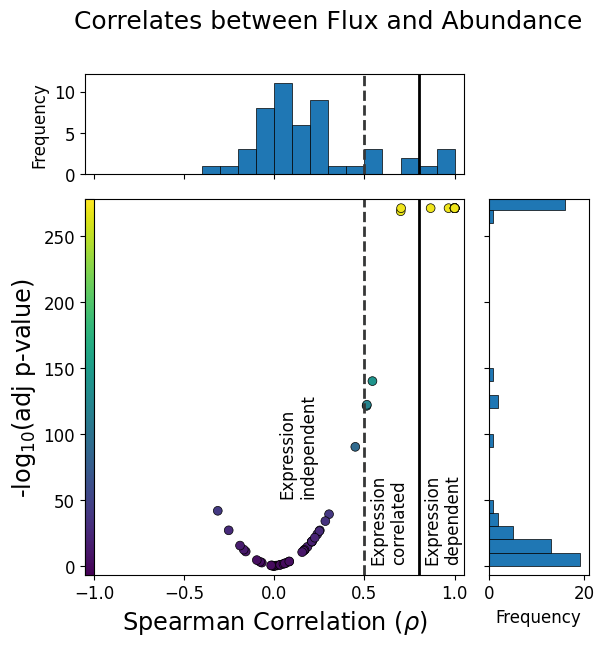

In [6]:
make_flux_abundance_u_plot(df_flux_abundance_correlation)

### Donut charts of subsystems

In [8]:
def make_subsystem_breakdown_by_abundance_dependence(
    df, abundance_dependence, figsize=(8, 8), title_y=1.2
):
    color_for_subsystem = {
        "Purine metabolism": "#332288",
        "Transport, extracellular": "#117733",
        "Porphyrin metabolism": "#44AA99",
        "Glycolysis / Gluconeogenesis": "#88CCEE",
        "Nicotinate and nicotinamide metabolism": "#999933",
        "Reactive species formation and detoxification": "#DDCC77",
        "Pentose phosphate pathway": "#CC6677",
        "Glutathione metabolism": "#882255",
        "Hemoglobin binding and degradation": "#882255",
        "Nucleotide metabolism": "#6699CC",
    }
    ring_series = df[df["abundance_dependence"] == abundance_dependence]["subsystem"]
    ring_series = ring_series.value_counts()
    wedge_labels = [
        f"{value}: {'\n'.join(textwrap.wrap(index, width=20))}"
        for index, value in ring_series.items()
    ]
    wedge_colors = [
        color_for_subsystem[subsystem] for subsystem, _ in ring_series.items()
    ]
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    wedges, texts = ax.pie(
        ring_series,
        labels=wedge_labels,
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        colors=wedge_colors,
        labeldistance=1.2,
    )
    center_circle = plt.Circle((0, 0), 0.5, fc="white")
    ax.add_artist(center_circle)
    ax.set_aspect("equal")
    plt.title(abundance_dependence, fontsize=14, y=title_y)

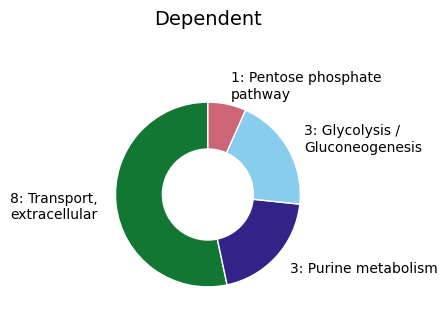

In [9]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation, abundance_dependence="Dependent", figsize=(3, 3)
)

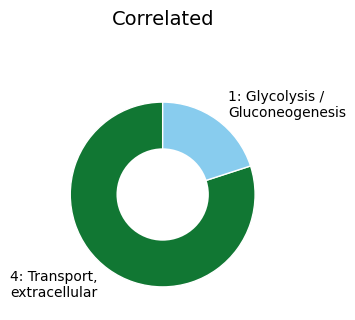

In [10]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation, abundance_dependence="Correlated", figsize=(3, 3)
)

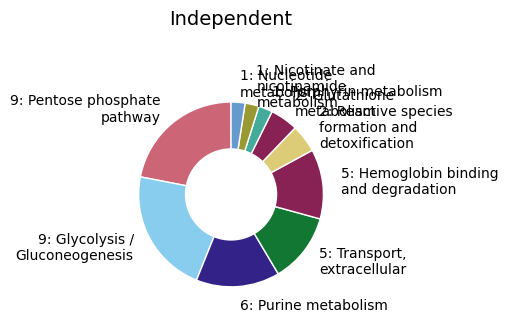

In [11]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation, abundance_dependence="Independent", figsize=(3, 3)
)